# Лекция №2

## Интерпретация кода на Python

Язык Python является *интерпретируемым*, то есть его исполняемый код выполняется **интерпретатором языка**.

*Интерпретатор должен быть установлен на компьютере*, где запускается программа на Python!

Существуют разные способы установки Python, но для начала мы посоветуем вам **локально установить Python + Jupyter**, следуя этой инструкции:
[Инструкция по установке Python и Jupyter локально](https://github.com/MSUcourses/Data-Analysis-with-Python/blob/main/Python/instructions/IDE-review.md).

[Видеоинструкция по локальной установке Python и Jupyter](https://rutube.ru/video/private/d59d46ba06e012c9aa81687e9e5fd33b/?p=5r_rISbwoQHzINsYBUuutA)

Если писать программный код в Google Colab, то ваши программы будут выполняться удаленно на серверах компании Google, а не на вашем компьютере. С одной стороны, это удобно, потому что вам не нужно ничего устанавливать, а с другой — вы перестаёте контролировать вычисления и делегируете хранение и исполнение программного кода третьим лицам, что не всегда допустимо.

### Версии языка Python

В данном курсе мы будем использовать версию Python 3. Подверсия, которая пишется через точку, не очень важна, но лучше, если у вас будет свежий интерпретатор, лучше всего Python 3.12.
Вы можете пользоваться и более ранними версиями, например, Python 3.11, 3.10 или 3.9. В них может не быть некоторых новых возможностей, но в целом синтаксис более поздних подверсий совместим с предыдущими.

Существовала и более старая версия, Python 2, но она считается морально устаревшей и почти не используется. Вторая версия Python на данный момент официально не поддерживается.
*Программы, написанные для Python 2, не будут работать на интерпретаторе Python 3*.

## Операционная система и прикладные процессы

Программное обеспечение делится на **системное ПО**, которое выполняет только служебные функции, и **прикладное ПО**, которое выполняет **прикладные задачи** пользователей. Поэтому программы и называются **приложениями**.

Программа, запущенная на исполнение, называется **вычислительным процессом** или просто *процессом*.
У каждого процесса на компьютере есть ограниченный запас ресурсов. Их распределяет **операционная система** (ОС).

ОС — *посредник* между аппаратурой и пользовательскими приложениями. Визуально можно отобразить это так:

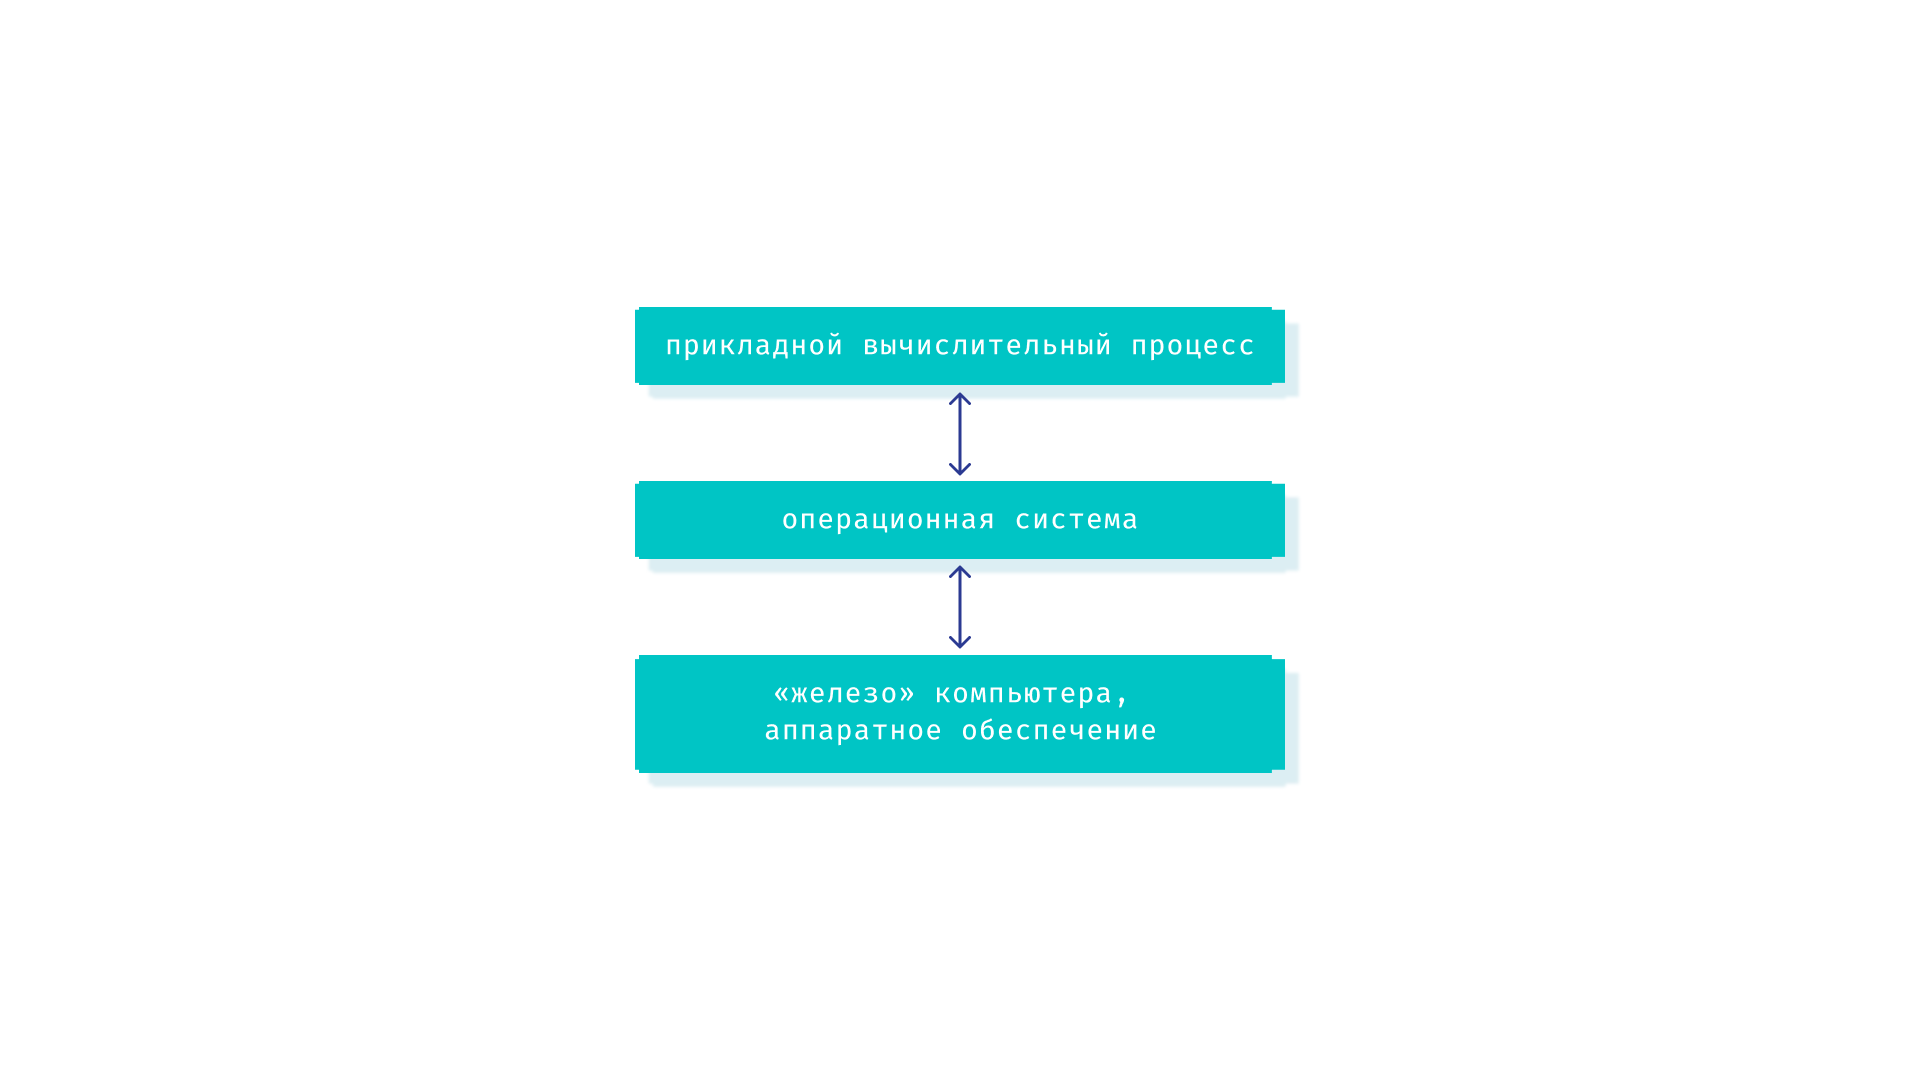

Один из самых важных ресурсов — это *оперативная память* (RAM) компьютера. Вычислительный процесс может запрашивать дополнительную память у операционной системы, но, если он не будет её освобождать после использования, ему просто перестанут её давать.

Для того, чтобы меньше думать о выделении и освобождении памяти, в Python есть **сборщик мусора**. Это автоматический помощник, который выбрасывает всё, на что программа больше не ссылается. Такая система называется "Автоматическая сборка мусора".

Если объект не назвать, он будет временным, но может успеть сослужить свою службу, поучаствовав в вычислении выражения.
У одного объекта может быть несколько имён. В большинстве случаев это совсем нестрашно, так как стандартные объекты чаще всего неизменяемые.

## Потоки ввода и вывода

Кроме памяти, любому вычислительному процессу ОС должна дать три стандартных потока для обмена информацией с пользователем.

1. Стандартный ввод (`stdin`) — поток 0
2. Стандартный вывод (`stdout`) — поток 1
3. Стандартный поток ошибок (`stderr`) — поток 2

С потоками 0 и 1 мы уже работали через функции `input()` и `print()`, однако с ними можно работать и другим способом, подключив модуль `sys`.

In [ ]:
import sys
sys.stdout.write("Hello, world!")

Hello, world!

Можно увидеть, что функция `write` возвращает 14 — количество выведенных символов.
А теперь попробуем воспользоваться потоком ошибок:

In [ ]:
sys.stderr.write("Это будет восприниматься как ошибка")

Это будет восприниматься как ошибка

То, что отправляется в поток ошибок, в Jupyter подсвечивается красным. (В Google Colab отображается так же, как вывод в поток 1.)

Поток ввода в консольных программах на Python также можно использовать через `sys.stdin`, однако в Jupyter это нельзя показать из-за его "магии".
Для считывания из потока используют функции `read()`, `readline()` или `readlines()`.

## Потоки для работы с файлами

Работа с текстовыми файлами, находящимися на жёстком диске, производится через специальные объекты, отвечающие за работу с потоком.
Часто такой объект называют "*файл*", поскольку он является представителем файла в рамках кода на Python.

Вычислительный процесс получает доступ к файлу только с ведома и одобрения ОС. Для этого:

1. Процесс должен явным образом запросить ОС **открыть файл**.
2. При открытии файла процесс должен **указать режим**: собирается ли он *читать из файла*, *писать в файл* или делать всё сразу.
3. Если файл открывается на чтение, то **файл должен существовать** по указанному пути.
4. Пользователь-хозяин процесса должен иметь право на открытие или создание данного файла.

Поток для работы с файлом появляется только в момент его успешного открытия функцией `open()`.

Создадим файл `my.txt` в текущей директории, где открыт данный Jupyter Notebook:

In [ ]:
file = open('my.txt', mode='w')

У объекта `file` для записи текста в файл есть метод `write()`:

In [ ]:
file.write("Ехал грека")

10

In [ ]:
file.write("Через реку")

10

In [ ]:
file.write("Видит грека -")

13

In [ ]:
file.write("В реке рак.")

11

Операционная система может *буферизовать ввод-вывод*, поэтому файл может не появиться или не обновить своё содержимое, пока мы явным образом не сбросим буфер или не закроем его.

In [ ]:
file.close()

**Закрывать файл по окончании работы с ним очень важно!**  Иначе файл будет заблокирован вычислительным процессом, и нельзя будет вытащить флешку с файлом или просто удалить файл.

Теперь можно посмотреть содержимое текстового файла в проводнике.

Также мы можем считать его в нашей программе с режимом `mode='r'`.

In [ ]:
file = open('my.txt', mode='r')
text = file.read()
file.close()
print(text)

Ехал грекаЧерез рекуВидит грека -В реке рак.


Строки, которые мы выводили, слились в одну. Дело в том, что **разрыв строки**, — это специальный невидимый символ.
Если мы хотим указать, что при печати текста из файла его нужно переносить, в месте переноса нужно ввести этот символ.

Cимволы переноса строки различаются в разных операционных системах. Это важно учитывать при работе с текстовыми файлами, особенно когда файлы передаются между разными ОС. В ОС Windows это два символа: CR (Carriage Return) и LF (Line Feed).

В строке Python перенос строки можно вставить комбинацией символов `"\n"`

In [ ]:
file = open('my.txt', mode='w')
file.write("Ехал грека\n")
file.write("Через реку\n")
file.write("Видит грека -\n")
file.write("В реке рак.\n")
file.close()

Теперь скороговорка выглядит правильно:

In [ ]:
file = open('my.txt', mode='r')
text = file.read()
file.close()
print(text)

Ехал грека
Через реку
Видит грека -
В реке рак.



## Кодировки текста

### Однобайтные кодировки и кодировка ASCII

Файлы на жёстком диске представляют из себя двоичные коды. При записи и считывании текста его нужно **закодировать**, а затем **декодировать**. Python сделал это автоматически, неявно выбрав какую-то **кодировку текста** (кодовую таблицу).

Чтобы явно указать кодировку нужно использовать в функции `open()` именованный параметр `encoding=`.

Давайте посмотрим что будет, если записать текст в файл в одной кодировке, а прочитать в другой:

In [ ]:
file = open('my.txt', mode='w', encoding='koi8-r')
file.write("Операторы связи: Мегафон, MTS, Теле2 и Beeline.")
file.close()

In [ ]:
file = open('my.txt', mode='r', encoding='cp1251')
text = file.read()
file.close()
print(text)

пРЕТБФПТЩ УЧСЪЙ: нЕЗБЖПО, MTS, фЕМЕ2 Й Beeline.


Этот эффект, возникающий вследствие неправильного декодирования, по-русски называют "кракозябры".

Мы использовали кодировки, в которых каждый символ кодируется ровно одним байтом. Однако одинаковым двоичным комбинациям соответствуют разные символы.

In [ ]:
koi8r = bytes(range(128, 256)).decode('koi8-r')
cp1251 = bytes(i for i in range(128, 256) if i != 152).decode('cp1251')
print(koi8r)
print(cp1251)

─│┌┐└┘├┤┬┴┼▀▄█▌▐░▒▓⌠■∙√≈≤≥ ⌡°²·÷═║╒ё╓╔╕╖╗╘╙╚╛╜╝╞╟╠╡Ё╢╣╤╥╦╧╨╩╪╫╬©юабцдефгхийклмнопярстужвьызшэщчъЮАБЦДЕФГХИЙКЛМНОПЯРСТУЖВЬЫЗШЭЩЧЪ
ЂЃ‚ѓ„…†‡€‰Љ‹ЊЌЋЏђ‘’“”•–—™љ›њќћџ ЎўЈ¤Ґ¦§Ё©Є«¬­®Ї°±Ііґµ¶·ё№є»јЅѕїАБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯабвгдежзийклмнопрстуфхцчшщъыьэюя


Однако среди "кракозябр" можно заметить пробелы, знаки препинания, латинские символы и цифры, которые, несмотря на выбор ошибочной таблицы, были декодированы правильно!

Дело в том, что и `koi8-r`, и `cp1251`, и многие другие однобайтные кодировки в первых 128 символах соответствуют ASCII.

In [ ]:
koi8r = bytes(range(0, 128)).decode('koi8-r')
cp1251 = bytes(range(0, 128)).decode('cp1251')
print(koi8r)
print(cp1251)

 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~
 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~


ASCII — это американская стандартная кодировка для обмена информацией, которая де-факто стала мировым стандартом.
Хорошо, когда кодировка универсальная, однако в ASCII слишком мало символов, что и привело к разнообразию однобайтных национальных кодировок.
Решением проблемы кодирования символов стала разработка **международного стандарта**.

### Кодировка Unicode

**Unicode** — это международный стандарт кодирования символов, который позволяет представить практически все письменные системы мира в цифровом виде.
Каждый символ, принятый организацией Unicode Consortium в универсальный набор символов UCS (Universal Character Set), получает **кодовую точку** — уникальный числовой идентификатор. Номер символа не зависит от платформы, программы или языка программирования.


Стандарт Unicode содержит уже более миллиона различных символов, и с каждым годом в нём появляются новые.

**UTF-8** (Unicode Transformation Format 8-bit) — это наиболее распространенная кодировка в сети Интернет, так как она обратно совместима с ASCII и эффективно использует память для латинских символов: первые 128 символов (ASCII) кодируются одним байтом, а остальные — несколькими байтами. На данный момент для представления любого символа требуется не более, чем 4 байта. Это касается даже китайских иероглифов.

В Python именно UTF-8 является стандартным способом кодирования строки `str`.

Для строки, содержащей ровно один символ, можно узнать его кодовую точку при помощи `ord()`.

In [ ]:
# Получение кодовой точки Unicode для символа
print(ord('A'))  # Выведет: 65
print(ord('я'))  # Выведет: 1103

65
1103


Наоборот, сгенерировать UTF-8 символ по его коду можно при помощи функции `chr()`.

In [ ]:
# Получение символа по кодовой точке Unicode
print(chr(65))   # Выведет: A
print(chr(1103)) # Выведет: я

A
я


In [ ]:
# Работа с эмодзи
print(ord('😊'))  # Выведет: 128522
print(chr(128522))  # Выведет: 😊

128522
😊


### Комментарии
Обратите внимание на символ `#` и текст после этого символа в предыдущих примерах.

Все, что расположено после символа `#`, считается комментарием, который не влияет на выполнение кода программы.

Комментарии нужны для человекопонятных пояснений, чтобы ваши коллеги по проекту (или вы сами спустя некоторое время) поняли (вспомнили), что выполняет та или иная часть кода.

## Тип `str`. Хранение строк в Python

Строки в Python хранятся в UTF-8, а значит, в одной строке могут соседствовать русские, греческие, грузинские и другие символы, включая Emoji.

In [ ]:
s = "\"Отче наш\" на грузинском — მამაო ჩვენო, а на греческом — Πάτερ ἡμῶν."
print(s)

"Отче наш" на грузинском — მამაო ჩვენო, а на греческом — Πάτερ ἡμῶν.


Чтобы узнать длину строки (количество символов в ней), нужно применить к ней функцию `len()`:

In [ ]:
print(len(s))

68


### Операции + и * со строками

In [ ]:
a = 'hello'
b = 'good bye'
print(a + b)
print(b + a)

hellogood bye
good byehello


Как видите, строки можно складывать. Такое сложение строк называется *конкатенация*, т.к. одна строка приклеивается к другой (кстати, в таком сложении `a + b` не равно `b + a`).

Строки можно также "умножать", но не друг на друга, а на число:

In [ ]:
"Help yourself!" * 3

'Help yourself!Help yourself!Help yourself!'

In [ ]:
"Help yourself!" * 5

'Help yourself!Help yourself!Help yourself!Help yourself!Help yourself!'

In [ ]:
"Help yourself!" * 0

''

In [ ]:
"Умножать строки друг на друга" * "нельзя"

TypeError: can't multiply sequence by non-int of type 'str'

## * Ошибки и как к ним правильно относиться.

Увы, иногда вы будете писать синтаксическую чушь, а интерпретатор будет "ругаться" на вас сообщениями об ошибках.
Очень важно не паниковать, а относиться к этому весело или хотя бы по-философски, т.е. спокойно. Нельзя учиться и не ошибаться. Ошибки по старой традиции называются bugs *("багами")*, а процесс их поиска, т.е. *отладка*, называется *debugging*.

Даже в программе, которую пишет профессионал, всегда есть ошибки, хотя не всегда они всплывают наружу. Иногда поиск и устранение одной ошибки требует от профессионала нескольких суток работы...

Запомните, **явная ошибка намного лучше, чем скрытая**, а значит, те ошибки, на которые интерпретатор "ругается", легко осознать и устранить. ПОЛЮБИТЕ сообщения об ошибках! Научитесь их *внимательно читать*.

В ошибке выше явно написана её причина: `"can't multiply sequence by non-int of type 'str'"`. А вид ошибки `TypeError` говорит нам, что это ошибка *типа*. То есть операция теоретически допустима, но с другим типом данных.

## * Интроспекция в Python
Давайте сравним два примера:


In [ ]:
5 + 7  # сложение чисел

12

In [ ]:
'5' + '7'  # сложение строк

'57'

Интерпретатор понимает, что в первом случае числа нужно сложить арифметически, а во втором "склеить" строки, хотя и в том, и в другом случае применяется одна и та же операция.

Оператор сложения ведет себя по-разному в зависимости от того, какого типа объекты являются операндами. В первом случае это числа (в `python` тип `int`), во втором случае это строки (тип `str`).

Определить тип объекта нам поможет функция `type`.

In [ ]:
name = "Hello, world!"
type(name)  # <--- здесь мы узнаём тип объекта строки

str

Что можно делать с объектом можно узнать у функции `dir`:

In [ ]:
dir(name)

['__add__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmod__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'capitalize',
 'casefold',
 'center',
 'count',
 'encode',
 'endswith',
 'expandtabs',
 'find',
 'format',
 'format_map',
 'index',
 'isalnum',
 'isalpha',
 'isascii',
 'isdecimal',
 'isdigit',
 'isidentifier',
 'islower',
 'isnumeric',
 'isprintable',
 'isspace',
 'istitle',
 'isupper',
 'join',
 'ljust',
 'lower',
 'lstrip',
 'maketrans',
 'partition',
 'removeprefix',
 'removesuffix',
 'replace',
 'rfind',
 'rindex',
 'rjust',
 'rpartition',
 'rsplit',
 'rstrip',
 'split',
 'splitlines',
 'startswith',
 'strip',
 'swapcase',


Здесь под видом `__add__` и `__mul__` указано, что к строке может применяться сложение и умножение. С опытом для вас всё вышеперечисленное будет означать больше.

### Доступ к символам строки по индексу

К символам строки можно обращаться по их индексам `s[i]`, где `i` начинается от `0` и доходит до `len(s) - 1`.

In [ ]:
s = "СТРОКА"

In [ ]:
for i in range(len(s)):
    print(s[i])

С
Т
Р
О
К
А


Обратите внимание, что всегда `s[len(s)]` будет давать ошибку IndexError.

In [ ]:
s[len(s)]

IndexError: string index out of range

К символам также можно получать доступ в обратном порядке — с конца. Например, `s[-1]` — это последний символ строки.

In [ ]:
s[-1]

'А'

`s[-len(s)]` не будет выдавать ошибки, т.к. это всего лишь 1-й символ строки (с индексом 0).

## Функция `range()` с двумя и тремя параметрами

Для перебора символов строки в обратном или другом специфическом порядке мы можем использовать функцию `range()` с двумя или тремя параметрами.

Объект, который возвращает функция `range(start, stop, step)`, — это **арифметическая прогрессия**.

Её `i`-й элемент равен `start + i * step`. Параметр `stop` нужен для ограничения количества элементов в ней.

Значения элементов `range()` не требуется хранить в памяти, поскольку они могут быть рассчитаны в любой момент по мере необходимости.

Чтобы увидеть значения элементов, их нужно перебрать при помощи цикла `for`:

In [ ]:
for x in range(0, 100, 20):
    print(x, end='\t')

0	20	40	60	80	

Заметим также, что `start` входит, а `stop` не входит в диапазон значений.

Если в `range` не указать третий параметр, то шаг прогрессии по умолчанию будет равен +1.

In [ ]:
for x in range(10, 20):
    print(x, end='\t')

10	11	12	13	14	15	16	17	18	19	

Отрицательный шаг имеет смысл, если `start` будет больше, чем `stop`:

In [ ]:
for x in range(20, 10, -1):
    print(x, end='\t')

20	19	18	17	16	15	14	13	12	11	

Заметим, что опять `start` вошёл, а `stop` не вошёл в диапазон.

Поэтому, если мы хотим получить значения от 19 до 10 включительно, нужно взять `range(19, 9, -1)`:

In [ ]:
for x in range(19, 9, -1):
    print(x, end='\t')

19	18	17	16	15	14	13	12	11	10	

Если от значения `start` нельзя добраться до значения `stop` прибавлением шага `step`, то диапазон оказывается пуст.
Цикл `for` в этом случае не совершит ни одной итерации:

In [ ]:
for x in range(20, 10, +1):
    print("Никогда не напечатается")

In [ ]:
for x in range(10, 20, -1):
    print("Никогда не напечатается")

Если перебирать индексы строки в соответствии с арифметической прогрессией, будут получаться подобные эффекты:

In [ ]:
s = "абракадабра"
for i in range(1, 4):
    print(s[i], end="")

бра

In [ ]:
s = "абракадабра"
for i in range(4, len(s)):
    print(s[i], end="")

кадабра

In [ ]:
s = "абракадабра"
for i in range(len(s)-1, -1, -1):
    print(s[i], end="")

арбадакарба

## Срезы строк

Для выделения из строки её части используются *срезы*. Самый простой срез — с одним параметром `s[i]`, который мы уже видели.

Важно понимать, что это именно срез, поскольку в Python нет отдельного типа для символов.

Строки типа `str` неизменяемы, а значит **присваивать в `s[i]` ничего нельзя**.

In [ ]:
s = "Строка"
s[0] = "S"

TypeError: 'str' object does not support item assignment

### Срезы с двумя параметрами:

In [ ]:
s = "абракадабра"
s[1:4]

'бра'

Была выбрана подстрока, содержащая с 1-го по 3-ий символы. Обратите внимание, что символ с индексом 4 не попал в срез.


В следующих 3-х примерах получается один и тот же результат.

In [ ]:
s[4:11]

'кадабра'

In [ ]:
s[4:len(s)] # len(s) = 11

'кадабра'

In [ ]:
s[4:]  # срез с двумя параметрами, хотя второй опущен. Получается как бы "до упора".

'кадабра'

Можно опускать и первый параметр. Тогда итоговый срез получится с 0-го символа.


In [ ]:
s[:4]

'абра'

In [ ]:
s[4:] + s[:4]

'кадабраабра'

In [ ]:
s[:]  # можно, но непонятно зачем... получается вся строка целиком


'абракадабра'

In [ ]:
s[4:20000]  # не вызывает ошибки, хотя 20 это явно больше количества символов в строке s

'кадабра'




### Срезы с тремя параметрами:

Общий вид среза с тремя параметрами такой: `s[start:stop:step].`


In [ ]:
s = "А роза упала на лапу Азора"
s[3:12:2] #выбирается каждый 2-ой с 3-го по 11-ый символ исходной строки

'оауаа'

In [ ]:
s[2:12:3] #выбирается каждый 3-ий символ с 2-го по 11-ый символ исходной строки

'рапа'

Мы можем получить срез исходной строки в обратном порядке, используя отрицательный шаг.

In [ ]:
s[len(s):-len(s)-1:-1]  # можно, но неудобно.

'арозА упал ан алапу азор А'

In [ ]:
s[::-1]  # а вот так —— удобно.

'арозА упал ан алапу азор А'

## Методы строки

Строка является **объектом**. Это значит, что у неё есть методы.

**Методы** — это функции, которые привязаны к конкретному объекту и вызываются через точку.
С их помощью можно интересным образом преобразовывать строку.

In [ ]:
s = "Hello, my DEAR friend!"
s

'Hello, my DEAR friend!'

In [ ]:
s.lower() #все буквы строки становятся строчными

'hello, my dear friend!'

In [ ]:
s.upper() #все буквы строки становятся заглавными

'HELLO, MY DEAR FRIEND!'

In [ ]:
s.title() #все слова в строке начинаются с заглавной буквы

'Hello, My Dear Friend!'

In [ ]:
s.replace('e', 'A') #буква e заменяется на A

'HAllo, my DEAR friAnd!'

Обратите внимание, что строка `s` при применении любых методов остаётся прежней, так как **строки `str` в Python неизменяемы**.

In [ ]:
s

'Hello, my DEAR friend!'

Если нам нужно сохранить результат, нужно явным образом присвоить его новой строке:

In [ ]:
new_s = s.replace('e', 'A')
print(new_s)

HAllo, my DEAR friAnd!


### Поиск подстроки в строке

Для поиска подстроки `sub` в строке `s` в строке можно использовать методы `count`, `find`, `rfind` и оператор `in`.

In [ ]:
s = "Abrakadabra"
sub = "ra"

`s.count(sub)` подсчитывает количество вхождений подстроки `sub` в строку `s`:

In [ ]:
s.count(sub)

2

`find` ищет первое вхождение с начала, а `rfind` — с конца (от reverse find).

Возвращают они индекс левого символа первого найденного вхождения подстроки. (Для `rfind` индекс тоже положительный.)

In [ ]:
s.find(sub)

2

In [ ]:
s.rfind(sub)

9

Если подстрока не является частью строки, `find` и `rfind` **возвращают -1**. Это признак того, что поиск неудачен.

In [ ]:
s = "Abrakadabra"
sub = "abc"
s.find(sub)

-1

Если место вхождения не важно, а нужно определить только факт вхождения, лучше использовать оператор `in` в следующей форме:

In [ ]:
sub in s

False

## Литералы строк
*Литерал строки* — это объект строки, непосредственно заданный в тексте программы.
В Python он может ограничиваться апострофами, кавычками, а в некоторых случаях даже тремя апострофами или тремя кавычками — и это не меняет тип объекта.

Внутри апострофов знак кавычки является просто символом, а внутри кавычек апостроф теряет свой синтаксический смысл.

Например, `"I'm a student."` удобнее написать в кавычках, а `'Я зарегистрировался в системе "Истина"'` - в апострофах.

In [ ]:
print("I'm a student.")
print('Я зарегистрировался в системе "Истина"')

I'm a student.
Я зарегистрировался в системе "Истина"


Если внутри литерала в кавычках нужно записать кавычку или в апострофах апостроф, то его можно экранировать обратной косой чертой (back slash): `"Фильм \"Д'Артаньян и три мушкетёра\"."`.

In [ ]:
print("Фильм \"Д'Артаньян и три мушкетёра\".")

Фильм "Д'Артаньян и три мушкетёра".


In [ ]:
s = '''"Преподаватель выдает студентам задание:
написать скрипт, который по номеру телефона определяет
географическое положение его владельца.
Первый студент пишет просто номер и получает 5 баллов.
Второй пишет город и получает 4 балла.
Третий - улицу и получает 3 балла.
Четвертый - дом и получает 2 балла.
Пятый - квартиру и полбалла.
Шестой - этаж и балл. Седьмой - комнату и 1 балл.
Восьмой - имя и 0 баллов."'''

s1 = "Не пугайтесь, это не задача" + ', а Балабоба от Яндекс:)'

print(s, s1, sep='\n\n')

"Преподаватель выдает студентам задание:
написать скрипт, который по номеру телефона определяет
географическое положение его владельца.
Первый студент пишет просто номер и получает 5 баллов.
Второй пишет город и получает 4 балла. 
Третий - улицу и получает 3 балла. 
Четвертый - дом и получает 2 балла. 
Пятый - квартиру и полбалла. 
Шестой - этаж и балл. Седьмой - комнату и 1 балл. 
Восьмой - имя и 0 баллов."

Не пугайтесь, это не задача, а Балабоба от Яндекс:)


## Сравнение строк. Лексикографический порядок

Строки можно сравнивать друг с другом операторами `==`, `!=`, `>`, `<`, `>=`, `<=`. При этом смысл "больше" и "меньше" — как у слов в словаре. Такой порядок называется *лексикографическим*. Для символов такое сравнение означает, что их коды в кодовой таблице Unicode находятся в таком же порядке.

In [ ]:
"А" < "Б"

True

In [ ]:
"Э" >= "Я"

False

In [ ]:
"Ю" <= "Ю"

True

In [ ]:
"слово" == "слово"

True

In [ ]:
"слово" != "слово"

False

## Подготовка к домашнему заданию

### Практические приёмы работы со строками

**Задача 1.** Равенство или вхождение как подстрока.

С потока ввода дано две строки. Требуется определить, равны ли строка 1 и строка 2, а если нет, то входит ли строка 2 входит в строку 1.

В случае равенства напечатать `equal`, в случае вхождения напечатать `inside`. В остальных случаях написать `no`.

In [ ]:
s1 = input()
s2 = input()
if s1 == s2:
    print("Equal")
elif s2 in s1:
    print("Inside")
else:
    print("No")

Строка
Строка
Equal


**Задача 2**. Применение срезов.

Дана строка. Требуется вывести её на экран с первым и последним символами, стоящими на местах друг друга.

In [ ]:
s = input()
print(s[-1] + s[1:-1] + s[0])

Параллелограмм
мараллелограмП


**Задача 3**. Поиск в строке и срезы.

Дана строка с текстом, содержащим телефонный номер в формате +7 987 654-32-10. Гарантируется, что кроме телефонного номера в строке не может быть других цифр и знака +. Телефонный номер в строке всегда либо один, либо его нет совсем.

Требуется выделить только сам телефонный номер и вывести его на печать. Если телефонный номер в данном формате в строке отсутствует, вывести слово `No`.

In [ ]:
text = input()
x = len("+7 987 654-32-10")
pos = text.find('+7')
if pos == -1:
    print("No")
else:
    print(text[pos:pos + x])

Вот мой номер телефона: +7 555 888-77-66, но лучше мне не звони.
+7 555 888-77-66


**Задача 4**. Замена.

Дана строка с текстом на русском языке. В тексте содержатся в частности цифры и буквы `ё` Требуется заменить все вхождения `ё` на `е` с учётом регистра, а все цифры просто удалить из текста.

In [ ]:
text = input()
text = text.replace('ё', 'е').replace('Ё', 'Е')
for digit in "0123456789":
    text = text.replace(digit, "")
print(text)

Ёлки и самолёты, ёжики и приёмы.
Елки и самолеты, ежики и приемы.


### *Строка как итерируемый объект
Для посимвольной обработки строки может использоваться цикл `for`. Он перебирает её, как монах перебирает чётки.



In [ ]:
for char in "ABCDE":
    print(char, '-', ord(char))  # здесь мы выводим каждый символ с его кодом UCS

A - 65
B - 66
C - 67
D - 68
E - 69


Действия, записанные в *теле цикла*, выполняются много раз: в данном случае — для каждой буквы.

Ниже представлен код, который выдаст результат, аналогичный коду выше.

In [ ]:
print("A", '-', ord("A"))
print("B", '-', ord("B"))
print("C", '-', ord("C"))
print("D", '-', ord("D"))
print("E", '-', ord("E"))

A - 65
B - 66
C - 67
D - 68
E - 69


Таких объектов, по которым можно **итерироваться** в языке, довольно много. Пока запомните, что они называются **итерируемыми объектами**.

### Описание функции `main()` для задач с файлами

В задачах, где требуется считывание из файла, вам нужно сдавать в проверяющую систему скрипт, содержащий функцию `main` с параметром `input_filename`.
В задачах с записью в файл — с параметром `output_filename`.
Для локального запуска такого скрипта функция `main()` вызывается внутри `if` следующим образом, при этом следует указывать имя файла в локальной директории, где вы будете запускать скрипт.

```python
def main(input_filename):
    file = open(input_filename, encoding='utf8')
    file.close()


if __name__ == '__main__':
    main("input.txt")
```

**Задача 5.** Работа с номерами символов и вывод в файл.

С потока ввода дана строка. Требуется зашифровать её по принципу шифра "Атбаш" и вывести в файл `output.txt` в кодировке `utf-8`.

Шифр Атбаш подразумевает замену буквы на симметричную в алфавите, то есть А заменяется на Я, Б на Ю, В на Э и так далее.

Гарантируется, что буквы Ё во входном потоке нет. Все символы, не входящие в русский алфавит, должны быть оставлены без изменений.

In [ ]:
def main(output_filename):
    file = open(output_filename, mode="w", encoding='utf8')
    s = input()
    for i in range(len(s)):
        if "а"  <= s[i] <= "я":
            c = chr(ord("я") - (ord(s[i]) - ord("а")))
        elif "А"  <= s[i] <= "Я":
            c = chr(ord("Я") - (ord(s[i]) - ord("А")))
        else:
            c = s[i]
        file.write(c)
    file.close()


if __name__ == '__main__':
    main("output.txt")

Russian capital alphabet: АБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ.


In [ ]:
with open("output.txt") as f:
    print(f.read())

Russian capital alphabet: ЯЮЭЬЫЪЩШЧЦХФУТСРПОНМЛКЙИЗЖЕДГВБА.


Выше для открытия файла на чтение мы воспользовались **менеджером контекста**, который гарантирует закрытие файла по окончании вложенного блока.

## * Где искать помощь?
У языка Python есть замечательная **документация** на сайте [docs.python.org](https://docs.python.org/3/).

Но даже если у вас нет Интернета, поможет функция `help`, встроенная в интерпретатор:

In [ ]:
help(str)

По вопросам синтаксических ошибок Python бывает удобно обращаться к поиску по сайту [STACK OVERFLOW](https://stackoverflow.com). На этом сайте разработчики помогают друг другу с возникающими проблемами: кто-то задает вопросы, кто-то отвечает на них. Там вы можете найти советы и решения для устранения полученной в программе ошибки.